In [37]:
import tiledb 
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

In [38]:
chrom='chr1'
index=171314056
flank=500
task_index=2 #index of ENCSR000EOT

In [39]:
db=tiledb.open("/srv/scratch/annashch/encode_dnase_tiledb/db/dnase",mode='r')
base_counts=db[index-flank:index+flank,2]['count_bigwig_unstranded_5p']

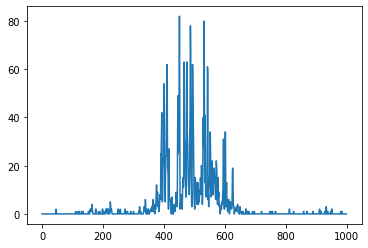

In [65]:
from matplotlib import pyplot as plt 
print(plt.plot(base_counts))

In [40]:
len(base_counts)

1000

In [41]:
N=sum(base_counts)
N

4246.0

In [42]:
k=2*flank

In [33]:
#manual calculation 

In [58]:
#assume a uniform distribution 
category_log_probs=np.log([1/k]*k)


In [57]:
log_n_fact = scipy.special.gammaln(N + 1)
print(log_n_fact)

31229.044623530204


In [59]:
log_counts_fact = scipy.special.gammaln(base_counts + 1)
log_counts_fact_sum = np.sum(log_counts_fact, axis=-1)
print(log_counts_fact_sum)

9307.14


In [60]:
log_prob_pows = category_log_probs * base_counts  # Elementwise
log_prob_pows_sum = np.sum(log_prob_pows, axis=-1)
print(log_prob_pows_sum)

-29330.328914558148


In [61]:
import scipy
def multinomial_log_probs(category_log_probs, trials, query_counts):
    log_n_fact = scipy.special.gammaln(trials + 1)
    log_counts_fact = scipy.special.gammaln(query_counts + 1)
    log_counts_fact_sum = np.sum(log_counts_fact, axis=-1)
    log_prob_pows = category_log_probs * query_counts  # Elementwise
    log_prob_pows_sum = np.sum(log_prob_pows, axis=-1)
    return log_n_fact - log_counts_fact_sum + log_prob_pows_sum

In [62]:
multinomial_log_probs(np.log([1/k]*k),N,base_counts)

-7408.423939465443

In [ ]:
##TF calculation ## 

In [ ]:
dist=tfp.distributions.Multinomial(total_count=N,probs=[1/k]*k)

In [ ]:
dist.prob(base_counts.tolist())